# Tankri OCR Model Evaluation

This notebook evaluates a trained Tankri OCR model using the saved checkpoint and validation data.
It does not train the model.


## 1. Imports

Import the libraries required for evaluation, visualization, and report generation.

In [2]:
import sys
from pathlib import Path
import os

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import *
from src.dataset import TankriDataset
from src.transforms import val_transform_resnet
from src.models import ResNet18Model
from src.evaluate import evaluate
from src.inference import load_model

# plt.style.use("seaborn-v0_8")
sns.set_context("notebook")

REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Imports complete")

Imports complete


## 2. Configuration and Device

Load configuration values and prepare the compute device.

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

checkpoint_path = PROJECT_ROOT /"notebooks" / "models" / "best_model.pth"
print(f"Checkpoint: {checkpoint_path}")

Using device: cuda
Checkpoint: D:\Dev\tankri_ocr_proj\notebooks\models\best_model.pth


## 3. Load Label Mappings

Rebuild label mappings from the filtered dataset so the notebook is self-contained.

In [8]:
df = pd.read_csv(LABELS_FILE)
counts = df["label"].value_counts()
valid_classes = counts[counts >= 2].index
df_filtered = df[df["label"].isin(valid_classes)].copy()

unique_labels = sorted(df_filtered["label"].unique())
label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}
NUM_CLASSES = len(unique_labels)

print(f"Loaded {NUM_CLASSES} classes")

Loaded 44 classes


## 4. Load Validation Dataset

Create the validation dataset and loader using the same split logic as training.

In [9]:
_, val_df = train_test_split(
    df_filtered,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=df_filtered["label"],
)

val_dataset = TankriDataset(
    dataframe=val_df,
    image_dir=IMAGES_DIR,
    label_to_idx=label_to_idx,
    transform=val_transform_resnet,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print(f"Validation samples: {len(val_dataset)}")

Validation samples: 76


## 5. Load Best Trained Model

Load the saved checkpoint from the models directory.

In [10]:
model = ResNet18Model(num_classes=NUM_CLASSES, pretrained=True)
model = model.to(device)

checkpoint = torch.load(checkpoint_path, map_location=device)
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model.eval()
print("Loaded best model checkpoint")

Loaded best model checkpoint


## 6. Overall Metrics

Compute validation loss and accuracy.

In [11]:
criterion = nn.CrossEntropyLoss()

val_loss = 0.0
correct = 0
total = 0

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        val_loss += loss.item()

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

val_loss = val_loss / len(val_loader)
val_accuracy = correct / total

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

Validation Loss: 1.4354
Validation Accuracy: 0.6842


## 7. Classification Report

Generate a detailed sklearn classification report.

In [12]:
y_true = np.array(y_true)
y_pred = np.array(y_pred)

present_labels = sorted(np.unique(np.concatenate([y_true, y_pred])))
present_target_names = [idx_to_label[idx] for idx in present_labels]

print(classification_report(
    y_true,
    y_pred,
    labels=present_labels,
    target_names=present_target_names,
    digits=3,
    zero_division=0,
))

              precision    recall  f1-score   support

           𑚀      0.800     1.000     0.889         4
          𑚀𑚫      1.000     1.000     1.000         4
          𑚀𑚬      1.000     1.000     1.000         2
           𑚁      1.000     0.750     0.857         4
           𑚂      0.500     1.000     0.667         3
           𑚃      0.667     0.500     0.571         4
           𑚄      0.750     0.750     0.750         4
           𑚅      1.000     1.000     1.000         3
           𑚆      0.800     1.000     0.889         4
           𑚇      0.750     0.750     0.750         4
           𑚈      0.500     0.500     0.500         4
           𑚉      0.600     0.750     0.667         4
           𑚊      1.000     0.500     0.667         2
           𑚋      0.000     0.000     0.000         1
           𑚌      0.500     1.000     0.667         1
           𑚍      1.000     1.000     1.000         1
           𑚏      0.500     1.000     0.667         1
           𑚐      1.000    

## 8. Per-Class Accuracy

Compute per-class accuracy, support, and sort from worst to best.

In [13]:
class_results = []
for cls_idx in present_labels:
    mask = y_true == cls_idx
    if mask.sum() == 0:
        continue
    correct = np.sum(y_pred[mask] == cls_idx)
    total = int(mask.sum())
    accuracy = correct / total
    class_results.append({
        "Character": idx_to_label[cls_idx],
        "Accuracy": accuracy,
        "Support": total,
        "Correct": correct,
    })

class_results_df = pd.DataFrame(class_results).sort_values("Accuracy")
class_results_df.head(10)

,Character,Accuracy,Support,Correct
26,𑚛,0.0,1,0
38,𑚧,0.0,1,0
37,𑚦,0.0,2,0
27,𑚜,0.0,1,0
22,𑚗,0.0,1,0
21,𑚖,0.0,1,0
39,𑚨,0.0,1,0
35,𑚤,0.0,1,0
34,𑚣,0.0,1,0
29,𑚞,0.0,1,0


## 9. Confusion Matrix

Plot the confusion matrix with Unicode labels and save it to the reports folder.

c:\Users\atmar\anaconda3\envs\aimlenv\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 71296 (\N{TAKRI LETTER A}) missing from current font.
  fig.canvas.draw()
c:\Users\atmar\anaconda3\envs\aimlenv\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 71339 (\N{TAKRI SIGN ANUSVARA}) missing from current font.
  fig.canvas.draw()
c:\Users\atmar\anaconda3\envs\aimlenv\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 71340 (\N{TAKRI SIGN VISARGA}) missing from current font.
  fig.canvas.draw()
c:\Users\atmar\anaconda3\envs\aimlenv\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 71297 (\N{TAKRI LETTER AA}) missing from current font.
  fig.canvas.draw()
c:\Users\atmar\anaconda3\envs\aimlenv\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 71298 (\N{TAKRI LETTER I}) missing from current font.
  fig.canvas.draw()
c:\Users\atmar\anaconda3\envs\aimlenv\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 71299 (\N{TAKRI LETTER II}) missing from cur

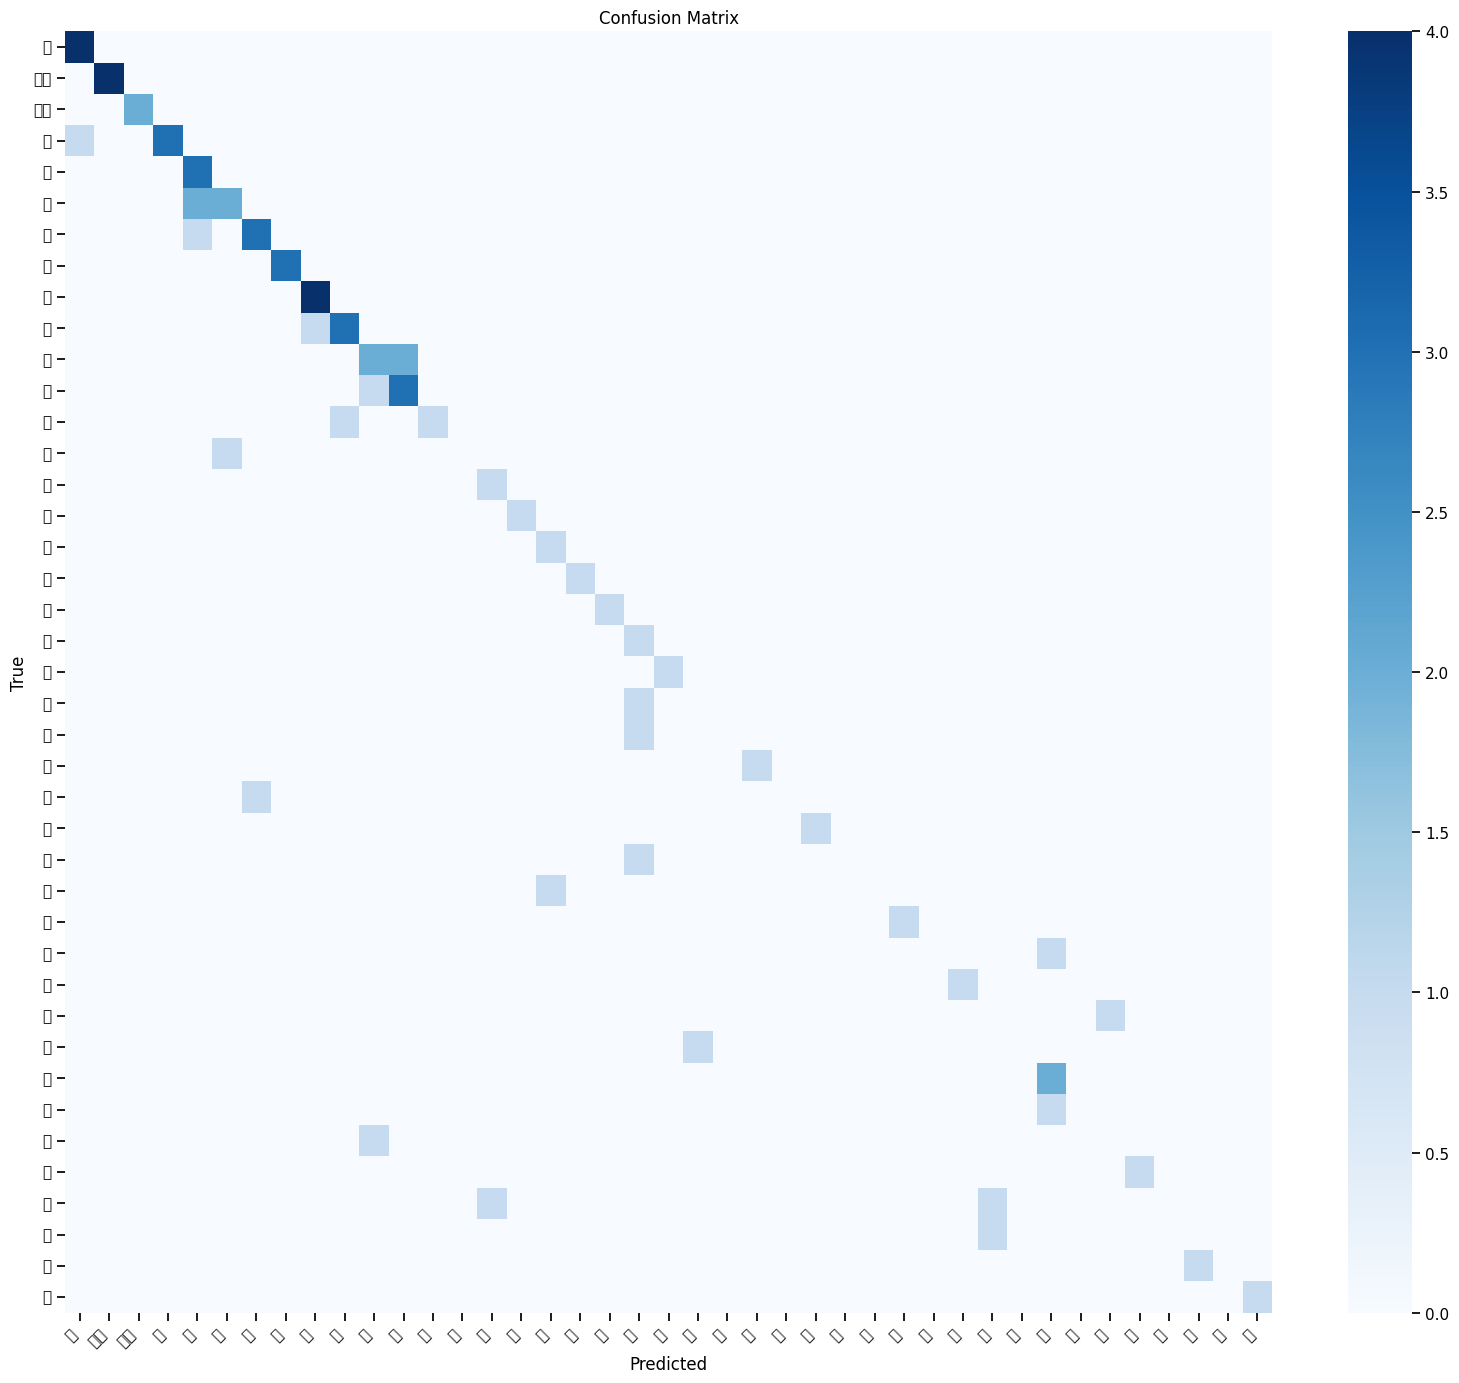

In [14]:
cm = confusion_matrix(y_true, y_pred, labels=present_labels)

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=[idx_to_label[idx] for idx in present_labels],
    yticklabels=[idx_to_label[idx] for idx in present_labels],
)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Top Confused Character Pairs

Find the most common off-diagonal misclassifications.

In [15]:
confusion_pairs = []
for i, true_idx in enumerate(present_labels):
    for j, pred_idx in enumerate(present_labels):
        if i != j and cm[i, j] > 0:
            confusion_pairs.append({
                "True": idx_to_label[true_idx],
                "Predicted": idx_to_label[pred_idx],
                "Count": int(cm[i, j]),
            })

confusion_pairs_df = pd.DataFrame(confusion_pairs).sort_values("Count", ascending=False)
confusion_pairs_df.head(15)

,True,Predicted,Count
4,𑚈,𑚉,2
1,𑚃,𑚂,2
0,𑚁,𑚀,1
12,𑚜,𑚏,1
20,𑚧,𑚠,1
19,𑚦,𑚠,1
18,𑚦,𑚌,1
17,𑚤,𑚈,1
16,𑚣,𑚢,1
15,𑚡,𑚖,1


## 11. Worst Performing Classes

Display the ten worst-performing classes.

In [16]:
class_results_df.head(10)

,Character,Accuracy,Support,Correct
26,𑚛,0.0,1,0
38,𑚧,0.0,1,0
37,𑚦,0.0,2,0
27,𑚜,0.0,1,0
22,𑚗,0.0,1,0
21,𑚖,0.0,1,0
39,𑚨,0.0,1,0
35,𑚤,0.0,1,0
34,𑚣,0.0,1,0
29,𑚞,0.0,1,0


## 12. Best Performing Classes

Display the ten best-performing classes.

In [17]:
class_results_df.sort_values("Accuracy", ascending=False).head(10)

,Character,Accuracy,Support,Correct
40,𑚩,1.0,1,1
30,𑚟,1.0,1,1
36,𑚥,1.0,1,1
33,𑚢,1.0,2,2
0,𑚀,1.0,4,4
20,𑚕,1.0,1,1
23,𑚘,1.0,1,1
19,𑚔,1.0,1,1
18,𑚑,1.0,1,1
17,𑚐,1.0,1,1


## 13. Misclassified Images Gallery

Show a sample of misclassified validation images.

TypeError: Invalid shape (3, 224, 224) for image data

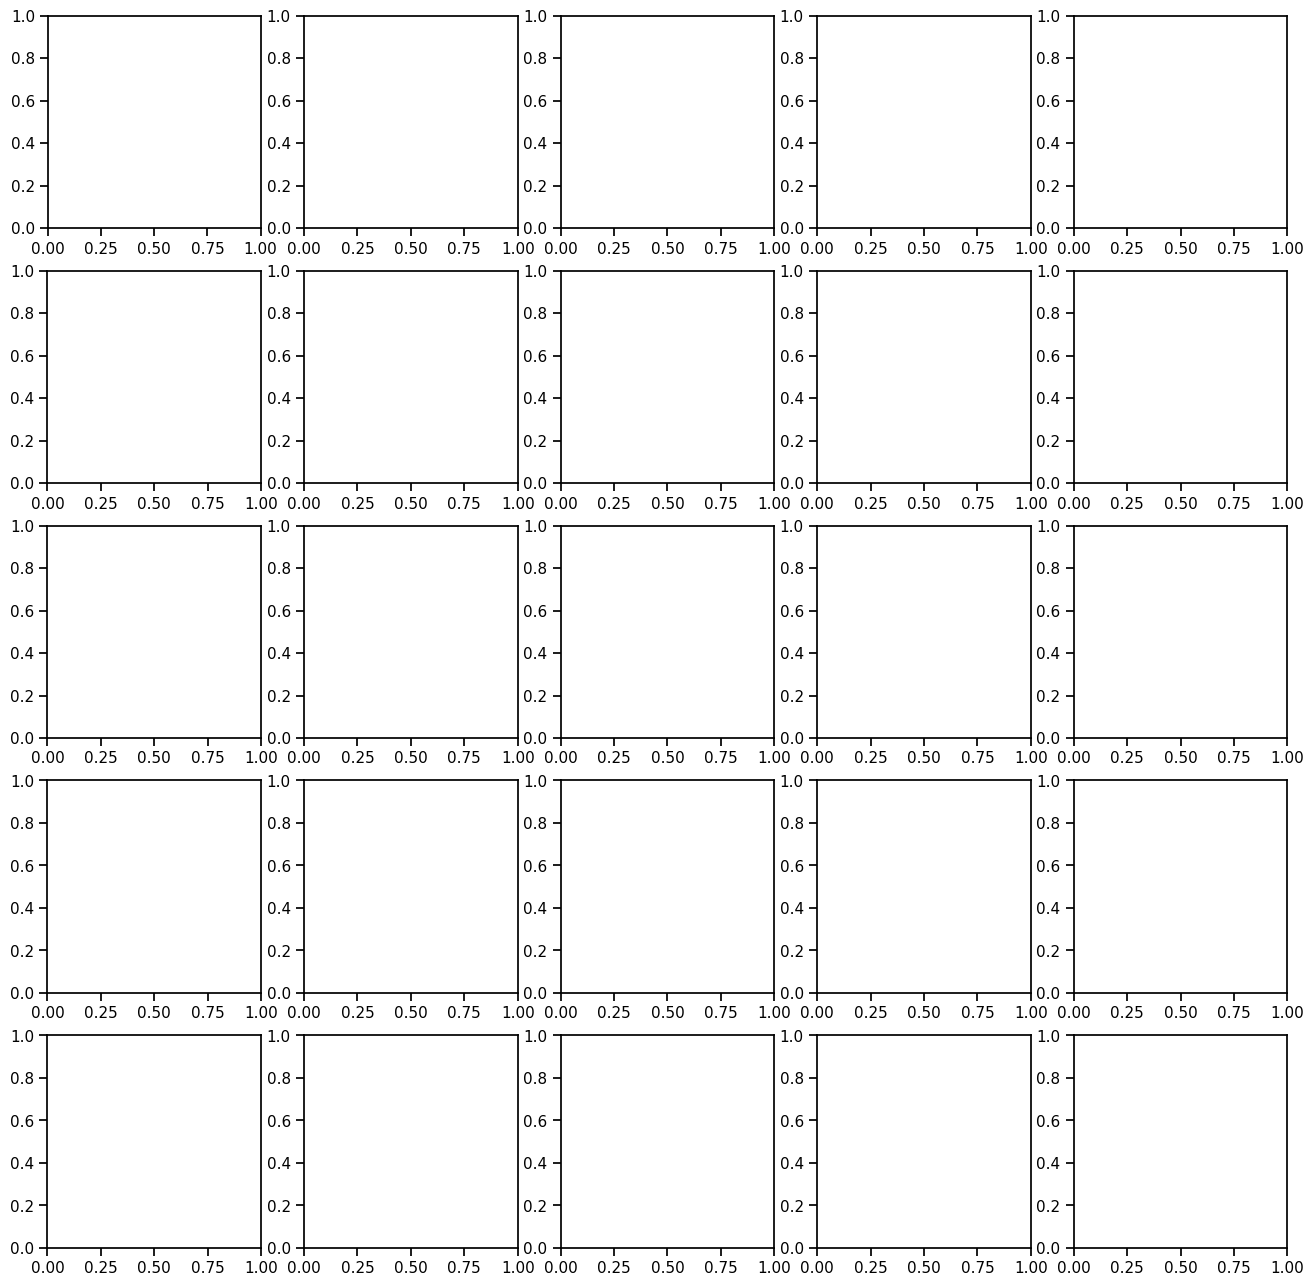

In [18]:
from PIL import Image

misclassified_indices = [
    idx for idx, (true_idx, pred_idx) in enumerate(zip(y_true, y_pred)) if true_idx != pred_idx
]

if len(misclassified_indices) > 0:
    sample_indices = np.random.choice(misclassified_indices, size=min(25, len(misclassified_indices)), replace=False)
    fig, axes = plt.subplots(5, 5, figsize=(16, 16))
    axes = axes.flatten()

    for ax, sample_idx in zip(axes, sample_indices):
        image, label = val_dataset[int(sample_idx)]
        true_label = idx_to_label[int(y_true[sample_idx])]
        pred_label = idx_to_label[int(y_pred[sample_idx])]
        ax.imshow(image.squeeze().numpy(), cmap="gray")
        ax.set_title(f"True: {true_label}\nPred: {pred_label}")
        ax.axis("off")

    for ax in axes[len(sample_indices):]:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(REPORTS_DIR / "misclassified_gallery.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No misclassified samples found")

## 14. Correct Predictions Gallery

Show a sample of correctly predicted validation images.

TypeError: Invalid shape (3, 224, 224) for image data

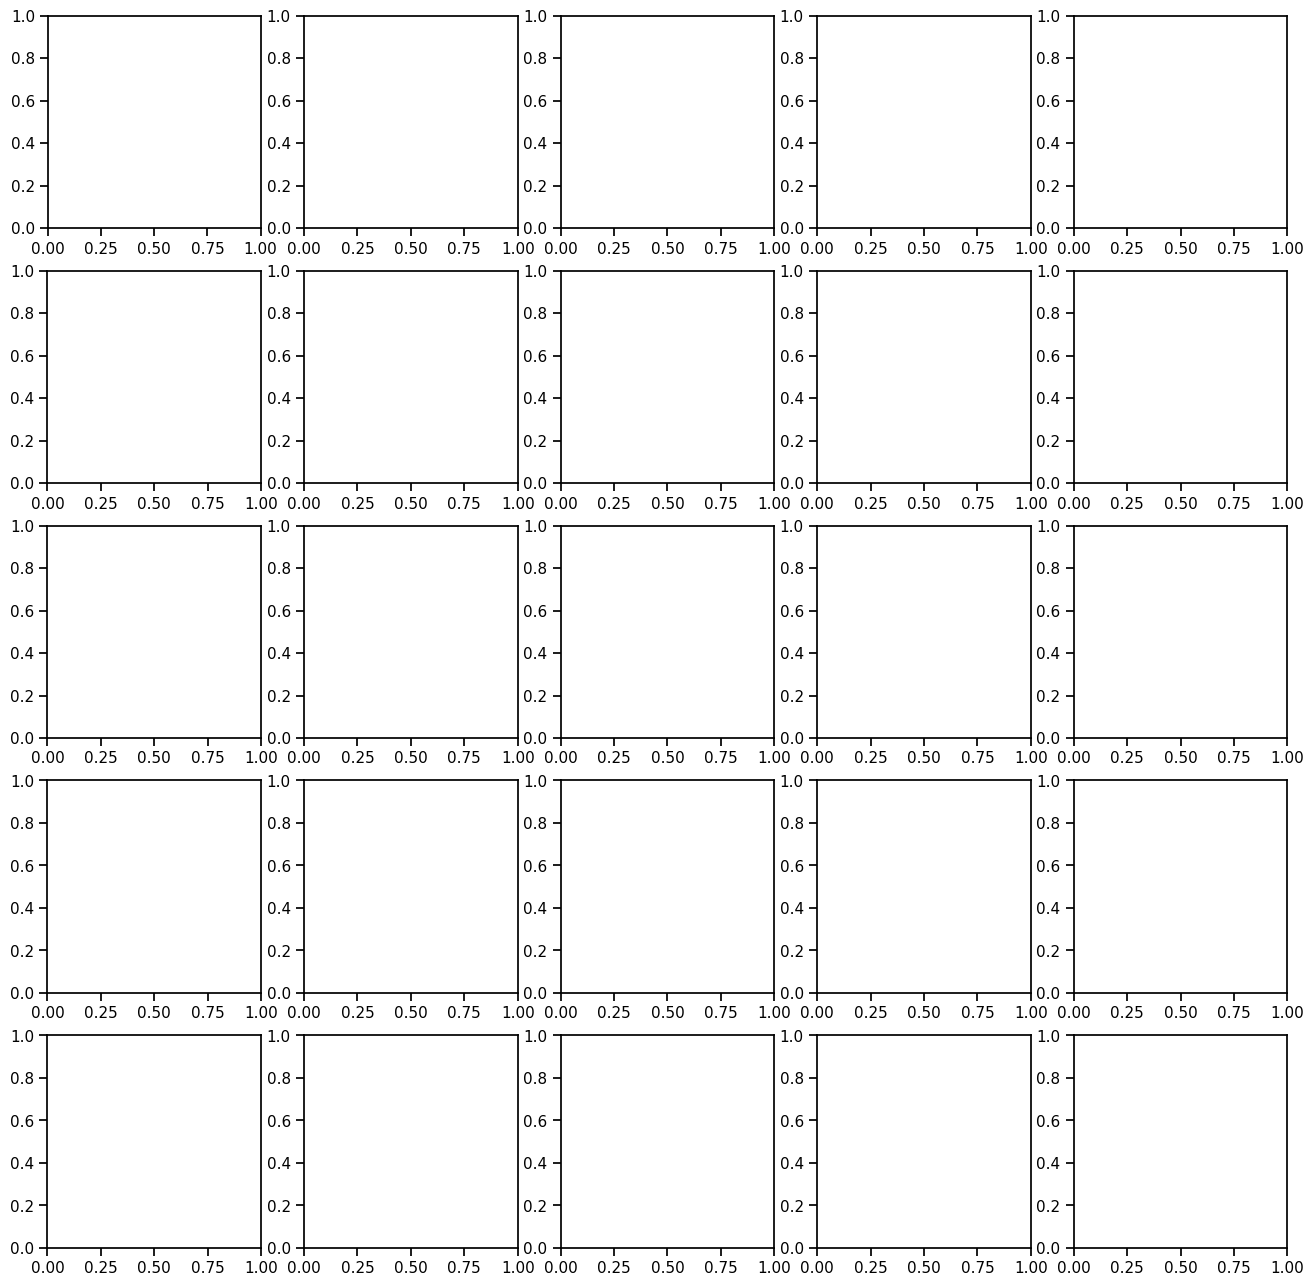

In [19]:
correct_indices = [
    idx for idx, (true_idx, pred_idx) in enumerate(zip(y_true, y_pred)) if true_idx == pred_idx
]

if len(correct_indices) > 0:
    sample_indices = np.random.choice(correct_indices, size=min(25, len(correct_indices)), replace=False)
    fig, axes = plt.subplots(5, 5, figsize=(16, 16))
    axes = axes.flatten()

    for ax, sample_idx in zip(axes, sample_indices):
        image, label = val_dataset[int(sample_idx)]
        true_label = idx_to_label[int(y_true[sample_idx])]
        ax.imshow(image.squeeze().numpy(), cmap="gray")
        ax.set_title(f"True: {true_label}")
        ax.axis("off")

    for ax in axes[len(sample_indices):]:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(REPORTS_DIR / "correct_gallery.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No correct samples found")

## 15. Confidence Analysis

Compute softmax confidence for correct and incorrect predictions.

In [20]:
all_probs = []
all_true = []
all_pred = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        confs, preds = probs.max(dim=1)
        all_probs.extend(confs.cpu().numpy())
        all_true.extend(labels.cpu().numpy())
        all_pred.extend(preds.cpu().numpy())

all_probs = np.array(all_probs)
all_true = np.array(all_true)
all_pred = np.array(all_pred)

correct_conf = pd.DataFrame({
    "Character": [idx_to_label[int(t)] for t in all_true[all_true == all_pred]],
    "Predicted": [idx_to_label[int(p)] for p in all_pred[all_true == all_pred]],
    "Confidence": all_probs[all_true == all_pred],
    "Correct": True,
}).sort_values("Confidence", ascending=False)

wrong_conf = pd.DataFrame({
    "Character": [idx_to_label[int(t)] for t in all_true[all_true != all_pred]],
    "Predicted": [idx_to_label[int(p)] for p in all_pred[all_true != all_pred]],
    "Confidence": all_probs[all_true != all_pred],
    "Correct": False,
}).sort_values("Confidence", ascending=False)

print("Most confident correct predictions:")
display(correct_conf.head(10))
print("\nMost confident wrong predictions:")
display(wrong_conf.head(10))

Most confident correct predictions:


,Character,Predicted,Confidence,Correct
17,𑚀𑚬,𑚀𑚬,0.927766,True
18,𑚉,𑚉,0.911260,True
51,𑚆,𑚆,0.876267,True
41,𑚀,𑚀,0.869348,True
34,𑚢,𑚢,0.865876,True
8,𑚀𑚬,𑚀𑚬,0.863009,True
30,𑚁,𑚁,0.843673,True
10,𑚀,𑚀,0.837963,True
3,𑚅,𑚅,0.825627,True
31,𑚂,𑚂,0.796964,True



Most confident wrong predictions:


,Character,Predicted,Confidence,Correct
5,𑚁,𑚀,0.807539,False
12,𑚊,𑚇,0.728734,False
2,𑚉,𑚈,0.640620,False
18,𑚃,𑚂,0.604217,False
11,𑚈,𑚉,0.503650,False
7,𑚋,𑚃,0.490581,False
9,𑚄,𑚂,0.478638,False
0,𑚈,𑚉,0.477029,False
23,𑚃,𑚂,0.415096,False
14,𑚇,𑚆,0.341886,False


## 16. Prediction Distribution

Compare actual and predicted class frequencies.

C:\Users\atmar\AppData\Local\Temp\ipykernel_8188\998921416.py:12: UserWarning: Glyph 71296 (\N{TAKRI LETTER A}) missing from current font.
  plt.tight_layout()
C:\Users\atmar\AppData\Local\Temp\ipykernel_8188\998921416.py:12: UserWarning: Glyph 71339 (\N{TAKRI SIGN ANUSVARA}) missing from current font.
  plt.tight_layout()
C:\Users\atmar\AppData\Local\Temp\ipykernel_8188\998921416.py:12: UserWarning: Glyph 71340 (\N{TAKRI SIGN VISARGA}) missing from current font.
  plt.tight_layout()
C:\Users\atmar\AppData\Local\Temp\ipykernel_8188\998921416.py:12: UserWarning: Glyph 71297 (\N{TAKRI LETTER AA}) missing from current font.
  plt.tight_layout()
C:\Users\atmar\AppData\Local\Temp\ipykernel_8188\998921416.py:12: UserWarning: Glyph 71298 (\N{TAKRI LETTER I}) missing from current font.
  plt.tight_layout()
C:\Users\atmar\AppData\Local\Temp\ipykernel_8188\998921416.py:12: UserWarning: Glyph 71299 (\N{TAKRI LETTER II}) missing from current font.
  plt.tight_layout()
C:\Users\atmar\AppData\Local\

<Figure size 1600x600 with 0 Axes>

c:\Users\atmar\anaconda3\envs\aimlenv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 71296 (\N{TAKRI LETTER A}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\atmar\anaconda3\envs\aimlenv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 71339 (\N{TAKRI SIGN ANUSVARA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\atmar\anaconda3\envs\aimlenv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 71340 (\N{TAKRI SIGN VISARGA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\atmar\anaconda3\envs\aimlenv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 71297 (\N{TAKRI LETTER AA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\atmar\anaconda3\envs\aimlenv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 71298 (\N{TAKRI LETTER I}) missing from current font.
  fig.canvas.prin

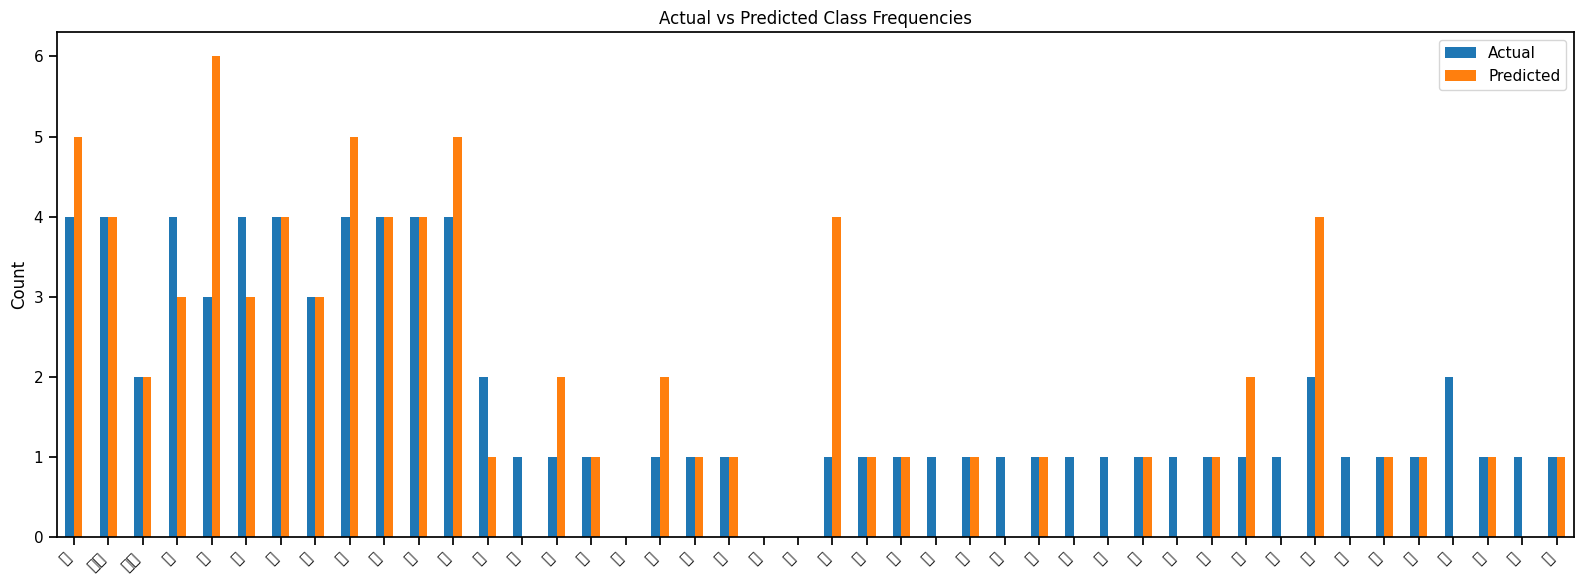

In [21]:
actual_counts = pd.Series(y_true).map(idx_to_label).value_counts().reindex(list(idx_to_label.values()), fill_value=0)
predicted_counts = pd.Series(y_pred).map(idx_to_label).value_counts().reindex(list(idx_to_label.values()), fill_value=0)

comparison_df = pd.DataFrame({"Actual": actual_counts, "Predicted": predicted_counts})
comparison_df = comparison_df.sort_index()

plt.figure(figsize=(16, 6))
comparison_df.plot(kind="bar", figsize=(16, 6))
plt.xticks(rotation=45, ha='right')
plt.title("Actual vs Predicted Class Frequencies")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "prediction_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 17. Save Evaluation Report

Export a CSV summary of evaluation metrics.

In [22]:
report_df = pd.DataFrame({
    "Character": [idx_to_label[idx] for idx in present_labels],
    "Support": [int((y_true == idx).sum()) for idx in present_labels],
    "Precision": [0.0] * len(present_labels),
    "Recall": [0.0] * len(present_labels),
    "F1": [0.0] * len(present_labels),
    "Accuracy": [0.0] * len(present_labels),
})

classification_report_dict = classification_report(
    y_true,
    y_pred,
    labels=present_labels,
    target_names=present_target_names,
    digits=3,
    output_dict=True,
    zero_division=0,
)

for idx, label in enumerate(present_target_names):
    metrics = classification_report_dict[label]
    report_df.loc[report_df["Character"] == label, "Precision"] = metrics["precision"]
    report_df.loc[report_df["Character"] == label, "Recall"] = metrics["recall"]
    report_df.loc[report_df["Character"] == label, "F1"] = metrics["f1-score"]
    report_df.loc[report_df["Character"] == label, "Accuracy"] = class_results_df.loc[class_results_df["Character"] == label, "Accuracy"].iloc[0]

report_df.to_csv(REPORTS_DIR / "evaluation_summary.csv", index=False)
report_df.head()

,Character,Support,Precision,Recall,F1,Accuracy
0,𑚀,4,0.8,1.00,0.888889,1.00
1,𑚀𑚫,4,1.0,1.00,1.000000,1.00
2,𑚀𑚬,2,1.0,1.00,1.000000,1.00
3,𑚁,4,1.0,0.75,0.857143,0.75
4,𑚂,3,0.5,1.00,0.666667,1.00
